### 第2章 像素和通道处理
#### 2.1 像素处理
- 二值图像和灰度图像

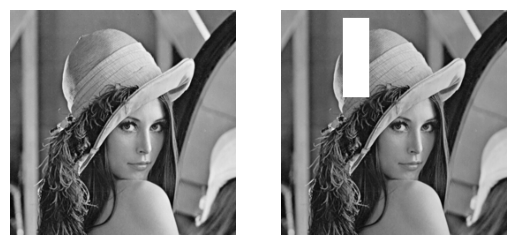

In [ ]:
# Jupyter Notebook 用 OpenCV 显示图像（内嵌不弹出独立窗口）
import matplotlib.pyplot as plt
%matplotlib inline

import cv2
img = cv2.imread("lena.bmp", 0)
# cv2.imshow("before", img)
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.axis('off')

for i in range(10, 100):
    for j in range(70, 100):
        img[i, j] = 255   # 设置交叉区域为白色
        
# cv2.imshow("after", img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

plt.subplot(1,2,2)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

- RGB 彩色图像

img=
 [[[255   0   0]
  [255   0   0]
  [255   0   0]
  ...
  [  0   0 255]
  [  0   0 255]
  [  0   0 255]]

 [[255   0   0]
  [255   0   0]
  [255   0   0]
  ...
  [  0   0 255]
  [  0   0 255]
  [  0   0 255]]

 [[255   0   0]
  [255   0   0]
  [255   0   0]
  ...
  [  0   0 255]
  [  0   0 255]
  [  0   0 255]]

 ...

 [[255   0   0]
  [255   0   0]
  [255   0   0]
  ...
  [  0   0 255]
  [  0   0 255]
  [  0   0 255]]

 [[255   0   0]
  [255   0   0]
  [255   0   0]
  ...
  [  0   0 255]
  [  0   0 255]
  [  0   0 255]]

 [[255   0   0]
  [255   0   0]
  [255   0   0]
  ...
  [  0   0 255]
  [  0   0 255]
  [  0   0 255]]]


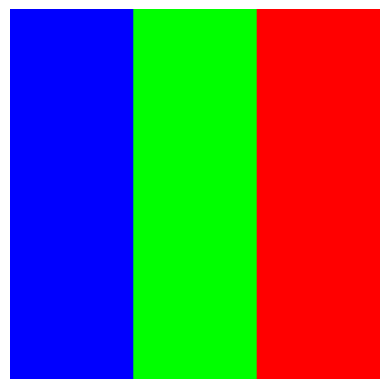

In [ ]:
import numpy as np
import cv2
img = np.zeros((300,300,3), dtype=np.uint8)
img[:, 0:100, 0] = 255 # 设置前100列的第0通道（B）为255，即蓝色区域
img[:, 100:200, 1] = 255 # 设置第100列到第200列的第1通道（G）为255，即绿色区域
img[:, 200:300, 2] = 255 # 设置第200列到第300列的第2通道（R）为255，即红色区域
print("img=\n", img)

# 注意：OpenCV 以BGR存储，使用 matplotlib 必须转换成 RGB，否则颜色失真
img= cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.show()

- 对彩色图像进行访问和修改

访问img[0,0]= [226 137 125]
访问img[0,0,0]= 226
访问img[0,0,1]= 137
访问img[0,0,2]= 125
访问img[50,0]= [230 136 114]
访问img[100,0]= [155  55  75]
修改后img[0,0]= [255 255 255]
修改后img[0,0,0]= 255
修改后img[0,0,1]= 255
修改后img[0,0,2]= 255
修改后img[50,0]= [128 128 128]
修改后img[100,0]= [0 0 0]


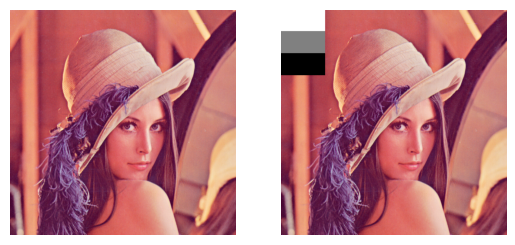

In [23]:
import cv2
img = cv2.imread("lenacolor.png")

plt.subplot(1,2,1)
img= cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis('off')

print("访问img[0,0]=", img[0, 0])
print("访问img[0,0,0]=", img[0, 0, 0])
print("访问img[0,0,1]=", img[0, 0, 1])
print("访问img[0,0,2]=", img[0, 0, 2])
print("访问img[50,0]=", img[50, 0])
print("访问img[100,0]=", img[100, 0])
#区域1
for i in range(0, 50):
    for j in range(0, 100):
        for k in range(0, 3):
            img[i, j, k] = 255  # 白色
#区域2
for i in range(50, 100):
    for j in range(0, 100):
        img[i, j] = (128, 128, 128)  # 灰色 元组元素不可变，更适于使用
#区域3            
for i in range(100, 150):
    for j in range(0, 100):
        img[i, j] = 0          # 黑色

print("修改后img[0,0]=", img[0, 0])
print("修改后img[0,0,0]=", img[0, 0, 0])
print("修改后img[0,0,1]=", img[0, 0, 1])
print("修改后img[0,0,2]=", img[0, 0, 2])
print("修改后img[50,0]=", img[50, 0])
print("修改后img[100,0]=", img[100, 0])

plt.subplot(1,2,2)
# img= cv2.cvtColor(img, cv2.COLOR_BGR2RGB)   # 已经转换过一次，不要重复转换
plt.imshow(img)
plt.axis('off')
plt.show()

#### 2.2 访问像素
- `item(row, column)`: 更高效地访问图像的像素点

访问img.item(0, 0, 0)= 226
访问img.item(0, 0, 1)= 137
访问img.item(0, 0, 2)= 125
修改后img.item(0,0,0)= 255
修改后img.item(0,0,1)= 255
修改后img.item(0,0,2)= 255


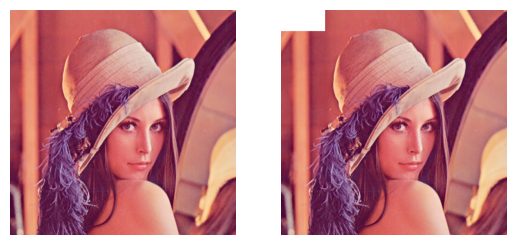

In [9]:
import cv2
img=cv2.imread("lenacolor.png")

plt.subplot(1,2,1)
img= cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis('off')

print("访问img.item(0, 0, 0)=", img.item(0, 0, 0))
print("访问img.item(0, 0, 1)=", img.item(0, 0, 1))
print("访问img.item(0, 0, 2)=", img.item(0, 0, 2))
for i in range(0, 50):
    for j in range(0, 100):
        for k in range(0, 3):
            # 在 NumPy 2.0 中，itemset 方法被移除，应替换为 img[i, j, k] = 255
            img[i, j, k] = 255     # 白色

print("修改后img.item(0,0,0)=", img.item(0, 0, 0))
print("修改后img.item(0,0,1)=", img.item(0, 0, 1))
print("修改后img.item(0,0,2)=", img.item(0, 0, 2))

plt.subplot(1,2,2)
plt.imshow(img)
plt.axis('off')
plt.show()

#### 2.3 感兴趣区域 (Region of Interest, ROI)
- 对 lena 图像的脸部进行打码

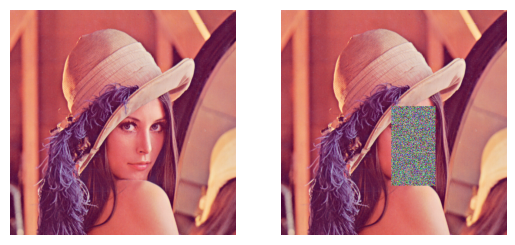

In [ ]:
import cv2
import numpy as np
a = cv2.imread("lenacolor.png", cv2.IMREAD_UNCHANGED)

plt.subplot(1,2,1)
a = cv2.cvtColor(a, cv2.COLOR_BGR2RGB)
plt.imshow(a)
plt.axis('off')

# 随机值ROI替换脸部
face = np.random.randint(0, 256, (180, 100, 3))
a[220:400, 250:350] = face

plt.subplot(1,2,2)
plt.imshow(a)
plt.axis('off')
plt.show()

- 将一幅图像的 ROI 复制到另一幅图像内

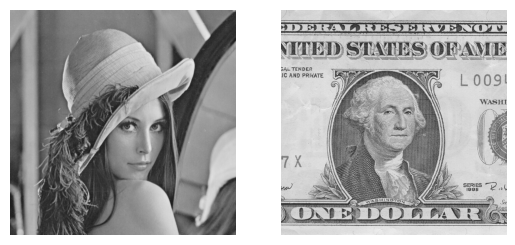

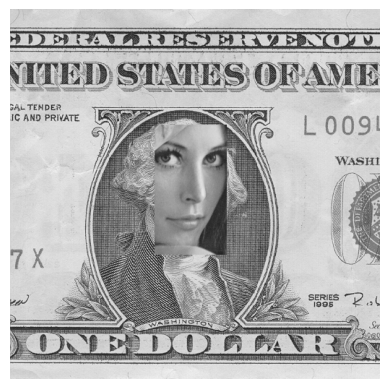

In [12]:
import cv2
lena = cv2.imread("lena512.bmp", cv2.IMREAD_UNCHANGED)
dollar = cv2.imread("dollar.bmp", cv2.IMREAD_UNCHANGED)

plt.subplot(1,2,1)
lena = cv2.cvtColor(lena, cv2.COLOR_BGR2RGB)
plt.imshow(lena)
plt.axis('off')
plt.subplot(1,2,2)
dollar = cv2.cvtColor(dollar, cv2.COLOR_BGR2RGB)
plt.imshow(dollar)
plt.axis('off')
plt.show()

# 第200行(包含)到第400行(不包含); 第250列(包含)到第350列(不包含)
face = lena[220:400, 250:350] 

dollar[160:340, 200:300] = face
plt.imshow(dollar)
plt.axis('off')
plt.show()

#### 2.4 通道操作
- 索引拆分
    - `b = img[:, :, 0]`
    - `g = img[:, :, 1]`
    - `r = img[:, :, 2]`
- 函数拆分
`b, g, r = cv2.split(img)` 等价于
    - `b = cv2.split(img)[0]`
    - `g = cv2.split(img)[1]`
    - `r = cv2.split(img)[2]`

(512, 512) (512, 512) (512, 512)
110


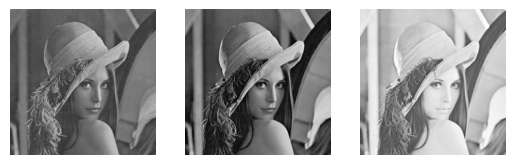

In [ ]:
import cv2
lena = cv2.imread("lenacolor.png", cv2.IMREAD_UNCHANGED)
b, g, r = cv2.split(lena)

print(b.shape, g.shape, r.shape)
print(b[220, 250])

plt.subplot(1,3,1)
b = cv2.cvtColor(b, cv2.COLOR_BGR2RGB)
plt.imshow(b)
plt.axis('off')
plt.subplot(1,3,2)
g = cv2.cvtColor(g, cv2.COLOR_BGR2RGB)
plt.imshow(g)
plt.axis('off')
plt.subplot(1,3,3)
r = cv2.cvtColor(r, cv2.COLOR_BGR2RGB)
plt.imshow(r)
plt.axis('off')
plt.show()

- 通道合并: `cv2.merge()`

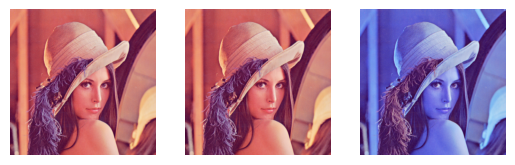

In [33]:
import cv2
lena = cv2.imread("lenacolor.png")
b, g, r = cv2.split(lena)
bgr = cv2.merge([b, g, r])
rgb = cv2.merge([r, g, b])

# cv2.imshow("lena", lena)
# cv2.imshow("bgr", bgr)  # OpenCV 中通道顺序是 BGR
# cv2.imshow("rgb", rgb)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

plt.subplot(1,3,1)
lena = cv2.cvtColor(lena, cv2.COLOR_BGR2RGB)
plt.imshow(lena)
plt.axis('off')
plt.subplot(1,3,2)
bgr = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
plt.imshow(bgr)
plt.axis('off')
plt.subplot(1,3,3)
rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
plt.imshow(rgb)
plt.axis('off')
plt.show()

- 获取图像属性

In [18]:
import cv2
gray = cv2.imread("lena.bmp",0)
color = cv2.imread("lenacolor.png")
print("图像gray属性：")
print("gray.shape=", gray.shape)
print("gray.size=", gray.size)
print("gray.dtype=", gray.dtype)
print("图像color属性：")
print("color.shape=", color.shape)
print("color.size=", color.size)
print("color.dtype=", color.dtype)

图像gray属性：
gray.shape= (256, 256)
gray.size= 65536
gray.dtype= uint8
图像color属性：
color.shape= (512, 512, 3)
color.size= 786432
color.dtype= uint8
